In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os

In [2]:
data_dir = os.getcwd()

In [3]:
full_sequence = ['ARG58',
 'LYS59',
 'TRP60',
 'ASN61',
 'PHE62',
 'ASP63',
 'PHE64',
 'GLN65',
 'ASN66',
 'HIS67',
 'LYS68',
 'PRO69',
 'LEU70',
 'GLU71',
 'GLY72',
 'LYS73',
 'TYR74',
 'GLU75',
 'ALA76',
 'GLN77',
 'GLU78',
 'VAL79',
 'GLU80',
 'LYS81',
 'GLY82',
 'SER83',
 'LEU84',
 'PRO85',
 'GLU86',
 'PHE87',
 'TYR88',
 'TYR89',
 'ARG90',
 'PRO91',
 'PRO92',
 'ARG93',
 'PRO94',
 'PRO95',
 'LYS96',
 'GLY97',
 'ALA98',
 'CYS99',
 'LYS100',
 'VAL101',
 'PRO102',
 'ALA103',
 'GLN104',
 'GLU105']

In [4]:
hc_sj4 = json.load(open(data_dir+'/SJ4/helix_contant.json', 'r'))
hc_sj4 = np.asarray(hc_sj4['rep:0'])

hc_sj7 = json.load(open(data_dir+'/SJ7/helix_contant.json', 'r'))
hc_sj7 = np.asarray(hc_sj7['rep:0'])

hc_sj9 = json.load(open(data_dir+'/SJ9/helix_contant.json', 'r'))
hc_sj9 = np.asarray(hc_sj9['rep:0'])

In [5]:
sc_sj4 = json.load(open(data_dir+'/SJ4/sheet_contant.json','r'))
sc_sj4 = np.asarray(sc_sj4['rep:0'])

sc_sj7 = json.load(open(data_dir+'/SJ7/sheet_contant.json','r'))
sc_sj7 = np.asarray(sc_sj7['rep:0'])

sc_sj9 = json.load(open(data_dir+'/SJ9/sheet_contant.json','r'))
sc_sj9 = np.asarray(sc_sj9['rep:0'])

In [6]:
bf_sj4 = np.asarray(json.load(open(data_dir+'/SJ4/avg_ligand_contacts.json', 'r'))['rep:0'])
bf_sj7 = np.asarray(json.load(open(data_dir+'/SJ7/avg_ligand_contacts.json', 'r'))['rep:0'])
bf_sj9 = np.asarray(json.load(open(data_dir+'/SJ9/avg_ligand_contacts.json', 'r'))['rep:0'])

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re

aa3to1 = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V',
    'HIE': 'H', 'HID': 'H', 'HIP': 'H',
    'CYX': 'C', 'CYM': 'C',
    'GLH': 'E', 'ASH': 'D',
}

def parse_residue_label(res_str):
    res_str = res_str.strip()
    m = re.match(r'([A-Za-z]+)[_ ]?(\d+)', res_str)
    if m:
        three, num = m.group(1).upper(), m.group(2)
        return f'{aa3to1.get(three, "?")}{num}'
    return res_str


def plot_structural_property(
    datasets,
    full_sequence=None,
    array_type='helix',
    ylabel=None,
    title=None,
    colors=None,
    percent_format=False,
    figsize=(14, 4),
    save_path=None,
):
    """
    Plot per-residue structural properties (helix, beta-sheet, or bound fraction)
    with shaded error bands.

    Parameters
    ----------
    datasets : dict
        { 'Label': array, ... }
        - helix / beta : array shape (N, 2)  — col0=fraction, col1=error
        - bound        : array shape (N, 3)  — col0=resnum, col1=fraction, col2=error
    full_sequence : list of str, optional
        Three-letter residue codes e.g. ['MET1', 'ARG2', ...].
        Required for helix/beta. For bound, used to map residue numbers to
        single-letter codes; falls back to plain numbers if not provided.
    array_type : str
        'helix', 'beta', or 'bound'
    ylabel : str, optional
        Y-axis label. Defaults to sensible value per array_type.
    title : str, optional
        Plot title. Defaults to sensible value per array_type.
    colors : dict, optional
        { 'Label': (line_color, fill_color), ... }
        Auto-assigned from a palette if not provided.
    percent_format : bool
        Format y-axis as percentage (0→0%, 1→100%). Default True.
    figsize : tuple
    save_path : str, optional
        If provided, save figure to this path.

    Returns
    -------
    fig, ax
    """

    is_bound = (array_type == 'bound')

    # ── Default labels / titles ──────────────────────────────────────────
    defaults = {
        'helix': ('Helix fraction',   'Helix propensity per residue'),
        'beta':  ('β-sheet fraction', 'β-sheet propensity per residue'),
        'bound': ('Bound fraction',   'Per-residue bound fraction'),
    }
    ylabel = ylabel or defaults.get(array_type, ('Fraction', 'Per-residue property'))[0]
    title  = title  or defaults.get(array_type, ('Fraction', 'Per-residue property'))[1]

    # ── Auto color palette ───────────────────────────────────────────────
    palette = [
        ('#1f77b4', '#aec7e8'),
        ('#d62728', '#f5a9a9'),
        ('#2ca02c', '#98df8a'),
        ('#9467bd', '#c5b0d5'),
        ('#e377c2', '#f7b6d2'),
        ('#8c564b', '#c49c94'),
    ]
    if colors is None:
        colors = {lbl: palette[i % len(palette)] for i, lbl in enumerate(datasets)}

    # ── Build single-letter label map from full_sequence ─────────────────
    label_map = {}
    if full_sequence is not None:
        for res_str in full_sequence:
            lbl = parse_residue_label(res_str)
            m = re.match(r'([A-Za-z])(\d+)', lbl)
            if m:
                label_map[int(m.group(2))] = lbl

    # ── Build x positions & tick labels ─────────────────────────────────
    if is_bound:
        first_arr = next(iter(datasets.values()))
        res_numbers = first_arr[:, 0].astype(int)
        x = np.arange(len(res_numbers))
        if label_map:
            x_labels = [label_map.get(r, str(r)) for r in res_numbers]
        else:
            x_labels = [str(r) for r in res_numbers]
    else:
        if full_sequence is None:
            raise ValueError("full_sequence is required for array_type='helix' or 'beta'")
        x_labels = [parse_residue_label(r) for r in full_sequence]
        x = np.arange(len(x_labels))

    # ── Plot ─────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    for label, arr in datasets.items():
        lc, fc = colors[label]
        if is_bound:
            mean  = arr[:, 1]
            error = arr[:, 2]
        else:
            mean  = arr[:, 0]
            error = arr[:, 1]

        ax.plot(x, mean, color=lc, linewidth=1.8, label=label)
        ax.fill_between(x, mean - error, mean + error,
                        color=fc, alpha=0.35)

    # ── Axes formatting ──────────────────────────────────────────────────

    
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=90, fontsize=10)  # increase x tick size here
    ax.tick_params(axis='y', labelsize=12)   
    
    ax.set_xlim(-0.5, len(x) - 0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel(ylabel, fontsize=15)
    ax.set_xlabel('Residue', fontsize=15)
    ax.set_title(title, fontsize=15)

    if percent_format:
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))

    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.legend(frameon=False, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()
    return fig, ax

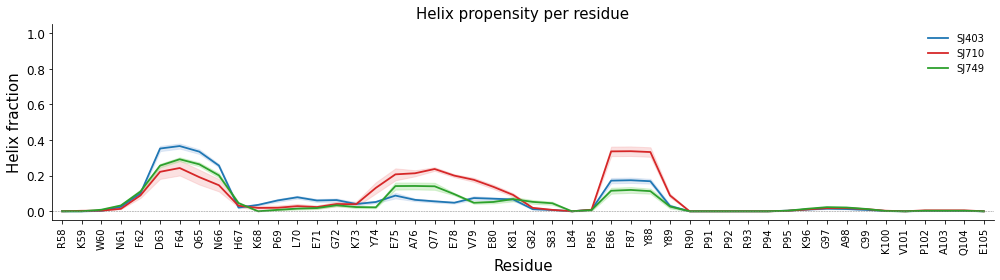

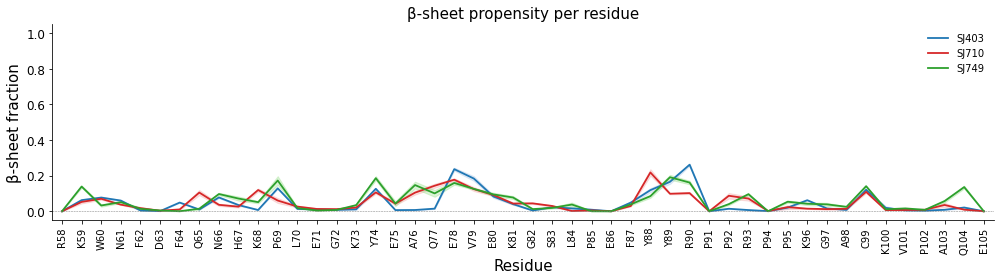

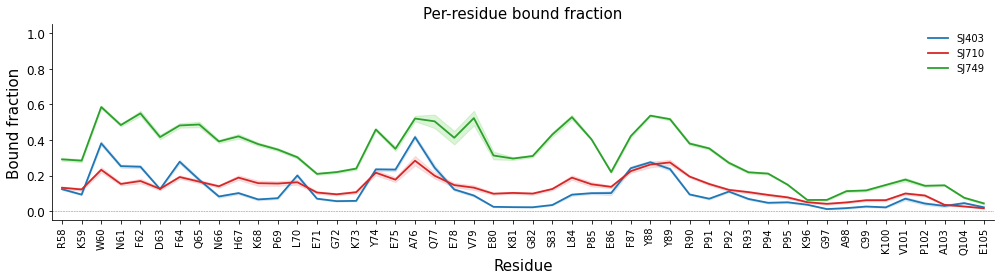

In [8]:
# Helix content
fig, ax = plot_structural_property(
    datasets={'SJ403': hc_sj4, 'SJ710': hc_sj7, 'SJ749': hc_sj9},
    full_sequence=full_sequence,
    array_type='helix',
)

# Beta-sheet content
fig, ax = plot_structural_property(
    datasets={'SJ403': sc_sj4, 'SJ710': sc_sj7, 'SJ749': sc_sj9},
    full_sequence=full_sequence,
    array_type='beta',
)

# Bound fraction — full_sequence now used to label x-axis with single-letter codes
fig, ax = plot_structural_property(
    datasets={'SJ403': bf_sj4, 'SJ710': bf_sj7, 'SJ749': bf_sj9},
    full_sequence=full_sequence,
    array_type='bound',
)

In [9]:
bf_sj7.shape

(48, 3)

In [17]:


# import re
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # -----------------------------------------------------------------------------
# # Parameters
# # -----------------------------------------------------------------------------
# EXCEL_PATH            = "WT_SJ4_800MHz.xlsx"
# SPEC_MHZ_1H           = 800.0
# GAMMA_N_OVER_GAMMA_H  = 0.10136767
# SPEC_MHZ_15N          = SPEC_MHZ_1H * GAMMA_N_OVER_GAMMA_H
# ALPHA_N               = 0.20

# RES_MIN, RES_MAX         = 58, 105
# THR_RES_MIN, THR_RES_MAX = 22, 105


# # -----------------------------------------------------------------------------
# # 1. Load and combine CSPs from the WT workbook (same as before)
# # -----------------------------------------------------------------------------
# def load_combined_csp(excel_path=EXCEL_PATH):
#     h = pd.read_excel(excel_path, sheet_name="1h-CSP (Hz)",  engine="openpyxl")
#     n = pd.read_excel(excel_path, sheet_name="15N-CSP (Hz)", engine="openpyxl")

#     h_col = h.columns[-1]
#     n_col = n.columns[-1]

#     # Drop non-numeric residue rows (sidechain peaks, blank separators)
#     h = h[pd.to_numeric(h["residue #"], errors="coerce").notna()].copy()
#     n = n[pd.to_numeric(n["residue #"], errors="coerce").notna()].copy()
#     h["residue #"] = h["residue #"].astype(int)
#     n["residue #"] = n["residue #"].astype(int)

#     merged = (
#         h[["residue #", "Residue", h_col]]
#         .merge(n[["residue #", n_col]], on="residue #", how="outer")
#         .sort_values("residue #")
#         .reset_index(drop=True)
#     )

#     dH_ppm = merged[h_col] / SPEC_MHZ_1H
#     dN_ppm = merged[n_col] / SPEC_MHZ_15N
#     csp_ppm = np.sqrt(dH_ppm.fillna(0) ** 2 + (ALPHA_N * dN_ppm.fillna(0)) ** 2)
#     both_nan = merged[h_col].isna() & merged[n_col].isna()
#     csp_ppm[both_nan] = np.nan
#     csp_hz = csp_ppm * SPEC_MHZ_1H

#     out = pd.DataFrame({
#         "resSeq":  merged["residue #"].astype(int),
#         "Residue": merged["Residue"],
#         "dH_ppm":  dH_ppm,
#         "dN_ppm":  dN_ppm,
#         "CSP_ppm": csp_ppm,
#         "CSP_Hz":  csp_hz,
#     })
#     out = (out.sort_values(["resSeq", "CSP_Hz"], na_position="last")
#               .drop_duplicates("resSeq", keep="first")
#               .reset_index(drop=True))
#     return out


# csp_df = load_combined_csp()

# # -----------------------------------------------------------------------------
# # 2. Threshold = mean + 2*std over residues 22-105 (on the Hz scale)
# # -----------------------------------------------------------------------------
# csp_thr_pool = csp_df.loc[
#     (csp_df["resSeq"] >= THR_RES_MIN) & (csp_df["resSeq"] <= THR_RES_MAX),
#     "CSP_Hz",
# ].dropna()
# csp_mean = csp_thr_pool.mean()
# csp_std  = csp_thr_pool.std(ddof=1)
# csp_threshold = csp_mean + 2 * csp_std
# print(f"CSP statistics over residues {THR_RES_MIN}-{THR_RES_MAX} "
#       f"(n={len(csp_thr_pool)}):")
# print(f"  mean = {csp_mean:.2f} Hz,  std = {csp_std:.2f} Hz")
# print(f"  threshold (mean + 2*std) = {csp_threshold:.2f} Hz")


# # -----------------------------------------------------------------------------
# # 3. Wrap the pre-computed bound-fraction array as a DataFrame
# # -----------------------------------------------------------------------------
# def bf_array_to_df(bf_arr):
#     """Convert an (N, 3) array [resSeq, bound_frac, error] -> DataFrame.

#     Anything outside the plotting window is silently dropped in step 4 below
#     via the reindex call, so this just does minimal cleanup (int resSeq,
#     drop duplicates if any).
#     """
#     bf_arr = np.asarray(bf_arr)
#     if bf_arr.ndim != 2 or bf_arr.shape[1] < 3:
#         raise ValueError(f"Expected (N, 3) array, got shape {bf_arr.shape}")
#     df = pd.DataFrame({
#         "resSeq":     bf_arr[:, 0].astype(int),
#         "bound_frac": bf_arr[:, 1].astype(float),
#         "sem":        bf_arr[:, 2].astype(float),
#     })
#     return df.drop_duplicates("resSeq").reset_index(drop=True)


# bf_df = bf_array_to_df(bf_sj4)

# # -----------------------------------------------------------------------------
# # 4. Align both to residues 58-105
# # -----------------------------------------------------------------------------
# res_range = np.arange(RES_MIN, RES_MAX + 1)
# csp_lookup = csp_df.drop_duplicates("resSeq").set_index("resSeq")
# bf_lookup  = bf_df .drop_duplicates("resSeq").set_index("resSeq")

# csp_p = csp_lookup.reindex(res_range).reset_index().rename(columns={"index": "resSeq"})
# bf_p  = bf_lookup .reindex(res_range).reset_index().rename(columns={"index": "resSeq"})

# assert len(csp_p) == len(bf_p) == len(res_range), \
#     f"length mismatch: csp={len(csp_p)}, bf={len(bf_p)}, expected={len(res_range)}"

# csp_p.merge(bf_p, on="resSeq", how="outer").to_csv(
#     "csp_and_boundfrac_SJ403_arrayBF_58-105.csv", index=False)
# print("Saved table -> csp_and_boundfrac_SJ403_arrayBF_58-105.csv")


# # -----------------------------------------------------------------------------
# # 5. Plot (identical style to the WT version; legend on the right)
# # -----------------------------------------------------------------------------
# _THREE_TO_ONE = {
#     "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
#     "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
#     "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
#     "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
#     "HID": "H", "HIE": "H", "HIP": "H", "HSD": "H", "HSE": "H", "HSP": "H",
# }


# def _tick_labels(csp_p):
#     labels = []
#     for _, row in csp_p.iterrows():
#         res_num = int(row["resSeq"])
#         name = row.get("Residue")
#         if isinstance(name, str) and name.strip():
#             name = name.strip()
#             if name[0].isalpha() and name[1:].lstrip("-").isdigit():
#                 labels.append(name)
#                 continue
#             three = name[:3].upper()
#             if three in _THREE_TO_ONE:
#                 labels.append(f"{_THREE_TO_ONE[three]}{res_num}")
#                 continue
#         labels.append(f".{res_num}")
#     return labels


# def plot_csp_with_boundfrac(
#     csp_p, bf_p, csp_threshold,
#     *,
#     title_fs=18,
#     axis_label_fs=16,
#     xtick_fs=11,
#     ytick_fs=13,
#     legend_fs=12,
#     figsize=None,
#     dpi=200,
#     out_prefix="csp_with_boundfrac_SJ403_arrayBF",
#     csp_color="#444444",
#     csp_above_color="#d62728",
#     bf_color="#1f77b4",
#     threshold_color="#d62728",
#     title="Experimental CSP (WT p27\u2013SJ403, 800 MHz) with bound fraction (array)",
#     bf_legend="Bound fraction (SJ403)",
#     err_legend="\u00b1 error",
#     legend_loc="upper right",
#     legend_bbox=None,
#     xtick_step=1,
#     show=True,
# ):
#     res = csp_p["resSeq"].values
#     csp = csp_p["CSP_Hz"].values
#     bf  = bf_p["bound_frac"].values
#     err = bf_p["sem"].values
#     labels = _tick_labels(csp_p)

#     n = len(res)
#     if figsize is None:
#         figsize = (max(10, n * 0.28), 5.8)

#     fig, ax = plt.subplots(figsize=figsize)

#     bar_colors = [
#         csp_above_color if (np.isfinite(c) and c >= csp_threshold) else csp_color
#         for c in csp
#     ]
#     bar_heights = np.where(np.isnan(csp), 0.0, csp)
#     ax.bar(res, bar_heights, color=bar_colors,
#            edgecolor="black", linewidth=0.3, label="CSP (Hz)")

#     ax.axhline(csp_threshold, color=threshold_color, linestyle="--",
#                linewidth=1.3,
#                label=f"Threshold = mean + 2\u03c3 ({csp_threshold:.1f} Hz)")

#     ax.set_xlabel("Residue", fontsize=axis_label_fs)
#     ax.set_ylabel('Expt. $\Delta \delta$ (Hz)', fontsize=axis_label_fs)
#     ax.set_title(title, fontsize=title_fs)
#     ax.tick_params(axis="y", labelsize=ytick_fs)
#     ax.set_xlim(res.min() - 0.5, res.max() + 0.5)

#     tick_idx = np.arange(0, n, xtick_step)
#     ax.set_xticks(res[tick_idx])
#     ax.set_xticklabels([labels[i] for i in tick_idx],
#                        rotation=90, fontsize=xtick_fs)
#     ax.spines["top"].set_visible(False)
#     ax.grid(axis="y", alpha=0.3, linewidth=0.5)

#     ax2 = ax.twinx()
#     valid = np.isfinite(bf)
#     ax2.plot(res[valid], bf[valid],
#              color=bf_color, lw=2, marker="o", ms=3.5, label=bf_legend)
#     ax2.fill_between(res[valid],
#                      (bf - err)[valid],
#                      (bf + err)[valid],
#                      color=bf_color, alpha=0.25, label=err_legend)
#     ax2.set_ylabel("Bound fraction", fontsize=axis_label_fs, color=bf_color)
#     ax2.tick_params(axis="y", labelsize=ytick_fs, colors=bf_color)
#     ax2.set_ylim(0, 0.4)
#     ax2.spines["top"].set_visible(False)

#     lines1, labels1 = ax.get_legend_handles_labels()
#     lines2, labels2 = ax2.get_legend_handles_labels()
#     leg_kwargs = dict(fontsize=legend_fs, frameon=True, framealpha=0.9)
#     if legend_bbox is not None:
#         leg_kwargs.update(dict(loc=legend_loc, bbox_to_anchor=legend_bbox,
#                                borderaxespad=0.))
#     else:
#         leg_kwargs["loc"] = legend_loc
#     ax2.legend(lines1 + lines2, labels1 + labels2, **leg_kwargs)

#     fig.tight_layout()
#     fig.savefig(f"{out_prefix}.png", dpi=dpi)
#     fig.savefig(f"{out_prefix}.pdf")
#     if show:
#         plt.show()
#     print(f"Saved plot -> {out_prefix}.png / .pdf")
#     return fig, ax, ax2


# plot_csp_with_boundfrac(csp_p, bf_p, csp_threshold)

CSP statistics over residues 22-105 (n=71):
  mean = 0.0078 ppm,  std = 0.0109 ppm
  threshold (mean + 2*std) = 0.0296 ppm
Saved table -> csp_and_boundfrac_SJ403_arrayBF_58-105.csv


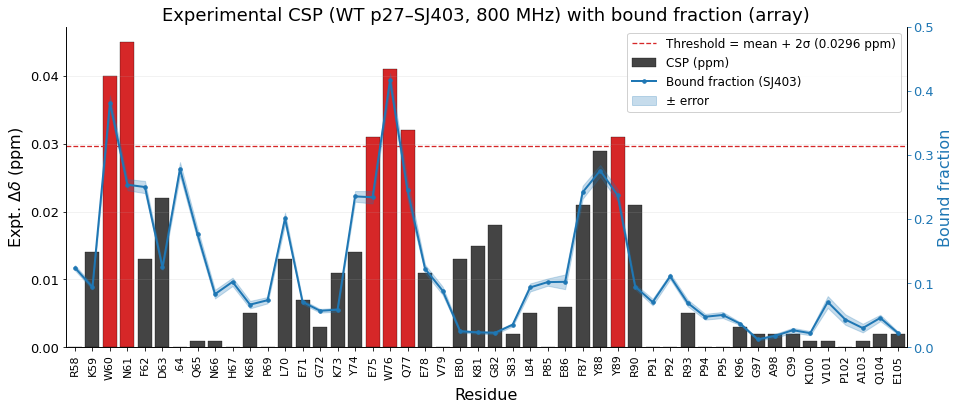

Saved plot -> csp_with_boundfrac_SJ403_arrayBF.png / .pdf


(<Figure size 967.68x417.6 with 2 Axes>,
 <AxesSubplot:title={'center':'Experimental CSP (WT p27–SJ403, 800 MHz) with bound fraction (array)'}, xlabel='Residue', ylabel='Expt. $\\Delta\\delta$ (ppm)'>,
 <AxesSubplot:ylabel='Bound fraction'>)

In [16]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------
EXCEL_PATH            = "WT_SJ4_800MHz.xlsx"
SPEC_MHZ_1H           = 800.0
GAMMA_N_OVER_GAMMA_H  = 0.10136767
SPEC_MHZ_15N          = SPEC_MHZ_1H * GAMMA_N_OVER_GAMMA_H
ALPHA_N               = 0.20

RES_MIN, RES_MAX         = 58, 105
THR_RES_MIN, THR_RES_MAX = 22, 105


# -----------------------------------------------------------------------------
# 1. Load and combine CSPs from the WT workbook
# -----------------------------------------------------------------------------
def load_combined_csp(excel_path=EXCEL_PATH):
    h = pd.read_excel(excel_path, sheet_name="1h-CSP (Hz)",  engine="openpyxl")
    n = pd.read_excel(excel_path, sheet_name="15N-CSP (Hz)", engine="openpyxl")

    h_col = h.columns[-1]
    n_col = n.columns[-1]

    h = h[pd.to_numeric(h["residue #"], errors="coerce").notna()].copy()
    n = n[pd.to_numeric(n["residue #"], errors="coerce").notna()].copy()
    h["residue #"] = h["residue #"].astype(int)
    n["residue #"] = n["residue #"].astype(int)

    merged = (
        h[["residue #", "Residue", h_col]]
        .merge(n[["residue #", n_col]], on="residue #", how="outer")
        .sort_values("residue #")
        .reset_index(drop=True)
    )

    dH_ppm = merged[h_col] / SPEC_MHZ_1H
    dN_ppm = merged[n_col] / SPEC_MHZ_15N
    csp_ppm = np.sqrt(dH_ppm.fillna(0) ** 2 + (ALPHA_N * dN_ppm.fillna(0)) ** 2)
    both_nan = merged[h_col].isna() & merged[n_col].isna()
    csp_ppm[both_nan] = np.nan
    csp_hz = csp_ppm * SPEC_MHZ_1H

    out = pd.DataFrame({
        "resSeq":  merged["residue #"].astype(int),
        "Residue": merged["Residue"],
        "dH_ppm":  dH_ppm,
        "dN_ppm":  dN_ppm,
        "CSP_ppm": csp_ppm,
        "CSP_Hz":  csp_hz,
    })
    out = (out.sort_values(["resSeq", "CSP_ppm"], na_position="last")  # sort by ppm
              .drop_duplicates("resSeq", keep="first")
              .reset_index(drop=True))
    return out


csp_df = load_combined_csp()

# -----------------------------------------------------------------------------
# 2. Threshold = mean + 2*std over residues 22-105 (NOW on the ppm scale)
# -----------------------------------------------------------------------------
csp_thr_pool = csp_df.loc[
    (csp_df["resSeq"] >= THR_RES_MIN) & (csp_df["resSeq"] <= THR_RES_MAX),
    "CSP_ppm",                          # <-- ppm
].dropna()
csp_mean = csp_thr_pool.mean()
csp_std  = csp_thr_pool.std(ddof=1)
csp_threshold = csp_mean + 2 * csp_std
print(f"CSP statistics over residues {THR_RES_MIN}-{THR_RES_MAX} "
      f"(n={len(csp_thr_pool)}):")
print(f"  mean = {csp_mean:.4f} ppm,  std = {csp_std:.4f} ppm")
print(f"  threshold (mean + 2*std) = {csp_threshold:.4f} ppm")


# -----------------------------------------------------------------------------
# 3. Wrap the pre-computed bound-fraction array as a DataFrame
# -----------------------------------------------------------------------------
def bf_array_to_df(bf_arr):
    bf_arr = np.asarray(bf_arr)
    if bf_arr.ndim != 2 or bf_arr.shape[1] < 3:
        raise ValueError(f"Expected (N, 3) array, got shape {bf_arr.shape}")
    df = pd.DataFrame({
        "resSeq":     bf_arr[:, 0].astype(int),
        "bound_frac": bf_arr[:, 1].astype(float),
        "sem":        bf_arr[:, 2].astype(float),
    })
    return df.drop_duplicates("resSeq").reset_index(drop=True)


bf_df = bf_array_to_df(bf_sj4)

# -----------------------------------------------------------------------------
# 4. Align both to residues 58-105
# -----------------------------------------------------------------------------
res_range = np.arange(RES_MIN, RES_MAX + 1)
csp_lookup = csp_df.drop_duplicates("resSeq").set_index("resSeq")
bf_lookup  = bf_df .drop_duplicates("resSeq").set_index("resSeq")

csp_p = csp_lookup.reindex(res_range).reset_index().rename(columns={"index": "resSeq"})
bf_p  = bf_lookup .reindex(res_range).reset_index().rename(columns={"index": "resSeq"})

assert len(csp_p) == len(bf_p) == len(res_range), \
    f"length mismatch: csp={len(csp_p)}, bf={len(bf_p)}, expected={len(res_range)}"

csp_p.merge(bf_p, on="resSeq", how="outer").to_csv(
    "csp_and_boundfrac_SJ403_arrayBF_58-105.csv", index=False)
print("Saved table -> csp_and_boundfrac_SJ403_arrayBF_58-105.csv")


# -----------------------------------------------------------------------------
# 5. Plot (y-axis now in ppm)
# -----------------------------------------------------------------------------
_THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "HID": "H", "HIE": "H", "HIP": "H", "HSD": "H", "HSE": "H", "HSP": "H",
}


def _tick_labels(csp_p):
    labels = []
    for _, row in csp_p.iterrows():
        res_num = int(row["resSeq"])
        name = row.get("Residue")
        if isinstance(name, str) and name.strip():
            name = name.strip()
            if name[0].isalpha() and name[1:].lstrip("-").isdigit():
                labels.append(name)
                continue
            three = name[:3].upper()
            if three in _THREE_TO_ONE:
                labels.append(f"{_THREE_TO_ONE[three]}{res_num}")
                continue
        labels.append(f".{res_num}")
    return labels


def plot_csp_with_boundfrac(
    csp_p, bf_p, csp_threshold,
    *,
    title_fs=18,
    axis_label_fs=16,
    xtick_fs=11,
    ytick_fs=13,
    legend_fs=12,
    figsize=None,
    dpi=200,
    out_prefix="csp_with_boundfrac_SJ403_arrayBF",
    csp_color="#444444",
    csp_above_color="#d62728",
    bf_color="#1f77b4",
    threshold_color="#d62728",
    title="Experimental CSP (WT p27\u2013SJ403, 800 MHz) with bound fraction (array)",
    bf_legend="Bound fraction (SJ403)",
    err_legend="\u00b1 error",
    legend_loc="upper right",
    legend_bbox=None,
    xtick_step=1,
    show=True,
):
    res = csp_p["resSeq"].values
    csp = csp_p["CSP_ppm"].values          # <-- ppm column
    bf  = bf_p["bound_frac"].values
    err = bf_p["sem"].values
    labels = _tick_labels(csp_p)

    n = len(res)
    if figsize is None:
        figsize = (max(10, n * 0.28), 5.8)

    fig, ax = plt.subplots(figsize=figsize)

    bar_colors = [
        csp_above_color if (np.isfinite(c) and c >= csp_threshold) else csp_color
        for c in csp
    ]
    bar_heights = np.where(np.isnan(csp), 0.0, csp)
    ax.bar(res, bar_heights, color=bar_colors,
           edgecolor="black", linewidth=0.3, label="CSP (ppm)")  # <-- label

    ax.axhline(csp_threshold, color=threshold_color, linestyle="--",
               linewidth=1.3,
               label=f"Threshold = mean + 2\u03c3 ({csp_threshold:.4f} ppm)")  # <-- ppm + 4 d.p.

    ax.set_xlabel("Residue", fontsize=axis_label_fs)
    ax.set_ylabel(r'Expt. $\Delta\delta$ (ppm)', fontsize=axis_label_fs)   # <-- ppm
    ax.set_title(title, fontsize=title_fs)
    ax.tick_params(axis="y", labelsize=ytick_fs)
    ax.set_xlim(res.min() - 0.5, res.max() + 0.5)

    tick_idx = np.arange(0, n, xtick_step)
    ax.set_xticks(res[tick_idx])
    ax.set_xticklabels([labels[i] for i in tick_idx],
                       rotation=90, fontsize=xtick_fs)
    ax.spines["top"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)

    ax2 = ax.twinx()
    valid = np.isfinite(bf)
    ax2.plot(res[valid], bf[valid],
             color=bf_color, lw=2, marker="o", ms=3.5, label=bf_legend)
    ax2.fill_between(res[valid],
                     (bf - err)[valid],
                     (bf + err)[valid],
                     color=bf_color, alpha=0.25, label=err_legend)
    ax2.set_ylabel("Bound fraction", fontsize=axis_label_fs, color=bf_color)
    ax2.tick_params(axis="y", labelsize=ytick_fs, colors=bf_color)
    ax2.set_ylim(0, 0.5)
    ax2.spines["top"].set_visible(False)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg_kwargs = dict(fontsize=legend_fs, frameon=True, framealpha=0.9)
    if legend_bbox is not None:
        leg_kwargs.update(dict(loc=legend_loc, bbox_to_anchor=legend_bbox,
                               borderaxespad=0.))
    else:
        leg_kwargs["loc"] = legend_loc
    ax2.legend(lines1 + lines2, labels1 + labels2, **leg_kwargs)

    fig.tight_layout()
    fig.savefig(f"{out_prefix}.png", dpi=dpi)
    fig.savefig(f"{out_prefix}.pdf")
    if show:
        plt.show()
    print(f"Saved plot -> {out_prefix}.png / .pdf")
    return fig, ax, ax2


plot_csp_with_boundfrac(csp_p, bf_p, csp_threshold)

In [11]:
'Expt. $\Delta \delta$ (Hz)'

'Expt. $\\Delta \\delta$ (Hz)'

SJ710 CSP statistics over residues 22-105 (n=69):
  mean = 5.80 Hz,  std = 3.85 Hz
  threshold (mean + 2*std) = 13.50 Hz
Saved table -> csp_and_boundfrac_SJ710_58-105.csv


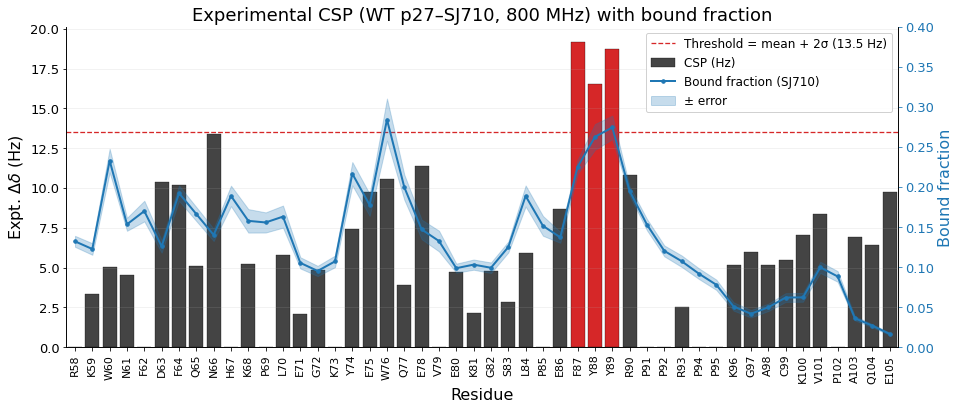

Saved plot -> csp_with_boundfrac_SJ710.png / .pdf


(<Figure size 967.68x417.6 with 2 Axes>,
 <AxesSubplot:title={'center':'Experimental CSP (WT p27–SJ710, 800 MHz) with bound fraction'}, xlabel='Residue', ylabel='Expt. $\\Delta \\delta$ (Hz)'>,
 <AxesSubplot:ylabel='Bound fraction'>)

In [12]:
"""
Experimental CSP (WT p27 + SJ710, 800 MHz) overlaid with a pre-computed
per-residue bound fraction.

Excel layout is the same as the WT_SJ403 file (two sheets with per-nucleus
CSPs in Hz, titration series `CSP[10]..CSP[3000]`, summary column at the
end). The only twist is sheet-name casing: this workbook uses `1H-CSP (Hz)`
(uppercase H) while the SJ403 one used `1h-CSP (Hz)` (lowercase). We find
sheets case-insensitively so the same loader handles both.

Inputs expected in memory:
    - `bf_sj7` : numpy array, shape (N, 3), columns = [resSeq, bf, error].
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------
EXCEL_PATH            = "WT_SJ710_800MHz.xlsx"
SPEC_MHZ_1H           = 800.0
GAMMA_N_OVER_GAMMA_H  = 0.10136767
SPEC_MHZ_15N          = SPEC_MHZ_1H * GAMMA_N_OVER_GAMMA_H
ALPHA_N               = 0.20

RES_MIN, RES_MAX         = 58, 105
THR_RES_MIN, THR_RES_MAX = 22, 105


# -----------------------------------------------------------------------------
# 1. Load and combine CSPs  — case-insensitive sheet lookup
# -----------------------------------------------------------------------------
def _find_sheet(xl, *needles):
    """Return the sheet whose name contains all substrings (case-insensitive)."""
    for s in xl.sheet_names:
        low = s.lower()
        if all(n.lower() in low for n in needles):
            return s
    raise KeyError(f"No sheet matching {needles} in {xl.sheet_names}")


def load_combined_csp(excel_path=EXCEL_PATH):
    xl = pd.ExcelFile(excel_path, engine="openpyxl")
    h_sheet = _find_sheet(xl, "1h",  "csp")
    n_sheet = _find_sheet(xl, "15n", "csp")
    h = pd.read_excel(xl, sheet_name=h_sheet)
    n = pd.read_excel(xl, sheet_name=n_sheet)

    # Per-nucleus summary column is the last one ('1H-CSP (Hz)' / '15N-CSP (Hz)')
    h_col = h.columns[-1]
    n_col = n.columns[-1]

    # Drop non-numeric residue rows (sidechain peaks, blank separators)
    h = h[pd.to_numeric(h["residue #"], errors="coerce").notna()].copy()
    n = n[pd.to_numeric(n["residue #"], errors="coerce").notna()].copy()
    h["residue #"] = h["residue #"].astype(int)
    n["residue #"] = n["residue #"].astype(int)

    merged = (
        h[["residue #", "Residue", h_col]]
        .merge(n[["residue #", n_col]], on="residue #", how="outer")
        .sort_values("residue #")
        .reset_index(drop=True)
    )

    dH_ppm = merged[h_col] / SPEC_MHZ_1H
    dN_ppm = merged[n_col] / SPEC_MHZ_15N
    csp_ppm = np.sqrt(dH_ppm.fillna(0) ** 2 + (ALPHA_N * dN_ppm.fillna(0)) ** 2)
    both_nan = merged[h_col].isna() & merged[n_col].isna()
    csp_ppm[both_nan] = np.nan
    csp_hz = csp_ppm * SPEC_MHZ_1H

    out = pd.DataFrame({
        "resSeq":  merged["residue #"].astype(int),
        "Residue": merged["Residue"],
        "dH_ppm":  dH_ppm,
        "dN_ppm":  dN_ppm,
        "CSP_ppm": csp_ppm,
        "CSP_Hz":  csp_hz,
    })
    out = (out.sort_values(["resSeq", "CSP_Hz"], na_position="last")
              .drop_duplicates("resSeq", keep="first")
              .reset_index(drop=True))
    return out


csp_df = load_combined_csp()

# -----------------------------------------------------------------------------
# 2. Threshold = mean + 2*std over residues 22-105 (Hz scale)
# -----------------------------------------------------------------------------
csp_thr_pool = csp_df.loc[
    (csp_df["resSeq"] >= THR_RES_MIN) & (csp_df["resSeq"] <= THR_RES_MAX),
    "CSP_Hz",
].dropna()
csp_mean = csp_thr_pool.mean()
csp_std  = csp_thr_pool.std(ddof=1)
csp_threshold = csp_mean + 2 * csp_std
print(f"SJ710 CSP statistics over residues {THR_RES_MIN}-{THR_RES_MAX} "
      f"(n={len(csp_thr_pool)}):")
print(f"  mean = {csp_mean:.2f} Hz,  std = {csp_std:.2f} Hz")
print(f"  threshold (mean + 2*std) = {csp_threshold:.2f} Hz")


# -----------------------------------------------------------------------------
# 3. Wrap the pre-computed bound-fraction array (bf_sj7) -> DataFrame
# -----------------------------------------------------------------------------
def bf_array_to_df(bf_arr):
    """Convert an (N, 3) array [resSeq, bound_frac, error] -> DataFrame."""
    bf_arr = np.asarray(bf_arr)
    if bf_arr.ndim != 2 or bf_arr.shape[1] < 3:
        raise ValueError(f"Expected (N, 3) array, got shape {bf_arr.shape}")
    df = pd.DataFrame({
        "resSeq":     bf_arr[:, 0].astype(int),
        "bound_frac": bf_arr[:, 1].astype(float),
        "sem":        bf_arr[:, 2].astype(float),
    })
    return df.drop_duplicates("resSeq").reset_index(drop=True)


bf_df = bf_array_to_df(bf_sj7)

# -----------------------------------------------------------------------------
# 4. Align both to residues 58-105
# -----------------------------------------------------------------------------
res_range = np.arange(RES_MIN, RES_MAX + 1)
csp_lookup = csp_df.drop_duplicates("resSeq").set_index("resSeq")
bf_lookup  = bf_df .drop_duplicates("resSeq").set_index("resSeq")

csp_p = csp_lookup.reindex(res_range).reset_index().rename(columns={"index": "resSeq"})
bf_p  = bf_lookup .reindex(res_range).reset_index().rename(columns={"index": "resSeq"})

assert len(csp_p) == len(bf_p) == len(res_range), \
    f"length mismatch: csp={len(csp_p)}, bf={len(bf_p)}, expected={len(res_range)}"

csp_p.merge(bf_p, on="resSeq", how="outer").to_csv(
    "csp_and_boundfrac_SJ710_58-105.csv", index=False)
print("Saved table -> csp_and_boundfrac_SJ710_58-105.csv")


# -----------------------------------------------------------------------------
# 5. Plot
# -----------------------------------------------------------------------------
_THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "HID": "H", "HIE": "H", "HIP": "H", "HSD": "H", "HSE": "H", "HSP": "H",
}


def _tick_labels(csp_p):
    labels = []
    for _, row in csp_p.iterrows():
        res_num = int(row["resSeq"])
        name = row.get("Residue")
        if isinstance(name, str) and name.strip():
            name = name.strip()
            if name[0].isalpha() and name[1:].lstrip("-").isdigit():
                labels.append(name)
                continue
            three = name[:3].upper()
            if three in _THREE_TO_ONE:
                labels.append(f"{_THREE_TO_ONE[three]}{res_num}")
                continue
        labels.append(f".{res_num}")
    return labels


def plot_csp_with_boundfrac(
    csp_p, bf_p, csp_threshold,
    *,
    title_fs=18,
    axis_label_fs=16,
    xtick_fs=11,
    ytick_fs=13,
    legend_fs=12,
    figsize=None,
    dpi=200,
    out_prefix="csp_with_boundfrac_SJ710",
    csp_color="#444444",
    csp_above_color="#d62728",
    bf_color="#1f77b4",
    threshold_color="#d62728",
    title="Experimental CSP (WT p27\u2013SJ710, 800 MHz) with bound fraction",
    bf_legend="Bound fraction (SJ710)",
    err_legend="\u00b1 error",
    legend_loc="upper right",
    legend_bbox=None,
    xtick_step=1,
    show=True,
):
    res = csp_p["resSeq"].values
    csp = csp_p["CSP_Hz"].values
    bf  = bf_p["bound_frac"].values
    err = bf_p["sem"].values
    labels = _tick_labels(csp_p)

    n = len(res)
    if figsize is None:
        figsize = (max(10, n * 0.28), 5.8)

    fig, ax = plt.subplots(figsize=figsize)

    bar_colors = [
        csp_above_color if (np.isfinite(c) and c >= csp_threshold) else csp_color
        for c in csp
    ]
    bar_heights = np.where(np.isnan(csp), 0.0, csp)
    ax.bar(res, bar_heights, color=bar_colors,
           edgecolor="black", linewidth=0.3, label="CSP (Hz)")

    ax.axhline(csp_threshold, color=threshold_color, linestyle="--",
               linewidth=1.3,
               label=f"Threshold = mean + 2\u03c3 ({csp_threshold:.1f} Hz)")
    
    # ax.axhline(10, color=threshold_color, linestyle="--",
    #            linewidth=1.3,
    #            label=f"Threshold = mean + 2\u03c3 ({csp_threshold:.1f} Hz)")

    ax.set_xlabel("Residue", fontsize=axis_label_fs)
    ax.set_ylabel('Expt. $\Delta \delta$ (Hz)', fontsize=axis_label_fs)
    ax.set_title(title, fontsize=title_fs)
    ax.tick_params(axis="y", labelsize=ytick_fs)
    ax.set_xlim(res.min() - 0.5, res.max() + 0.5)

    tick_idx = np.arange(0, n, xtick_step)
    ax.set_xticks(res[tick_idx])
    ax.set_xticklabels([labels[i] for i in tick_idx],
                       rotation=90, fontsize=xtick_fs)
    ax.spines["top"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)

    ax2 = ax.twinx()
    valid = np.isfinite(bf)
    ax2.plot(res[valid], bf[valid],
             color=bf_color, lw=2, marker="o", ms=3.5, label=bf_legend)
    ax2.fill_between(res[valid],
                     (bf - err)[valid],
                     (bf + err)[valid],
                     color=bf_color, alpha=0.25, label=err_legend)
    ax2.set_ylabel("Bound fraction", fontsize=axis_label_fs, color=bf_color)
    ax2.tick_params(axis="y", labelsize=ytick_fs, colors=bf_color)
    ax2.set_ylim(0, 0.4)
    ax2.spines["top"].set_visible(False)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg_kwargs = dict(fontsize=legend_fs, frameon=True, framealpha=0.9)
    if legend_bbox is not None:
        leg_kwargs.update(dict(loc=legend_loc, bbox_to_anchor=legend_bbox,
                               borderaxespad=0.))
    else:
        leg_kwargs["loc"] = legend_loc
    ax2.legend(lines1 + lines2, labels1 + labels2, **leg_kwargs)

    fig.tight_layout()
    fig.savefig(f"{out_prefix}.png", dpi=dpi)
    fig.savefig(f"{out_prefix}.pdf")
    if show:
        plt.show()
    print(f"Saved plot -> {out_prefix}.png / .pdf")
    return fig, ax, ax2


plot_csp_with_boundfrac(csp_p, bf_p, csp_threshold)

SJ710 CSP statistics over residues 22-105 (n=69):
  mean = 0.01 Hz,  std = 0.00 Hz
  threshold (mean + 2*std) = 0.02 Hz
Saved table -> csp_and_boundfrac_SJ710_58-105.csv


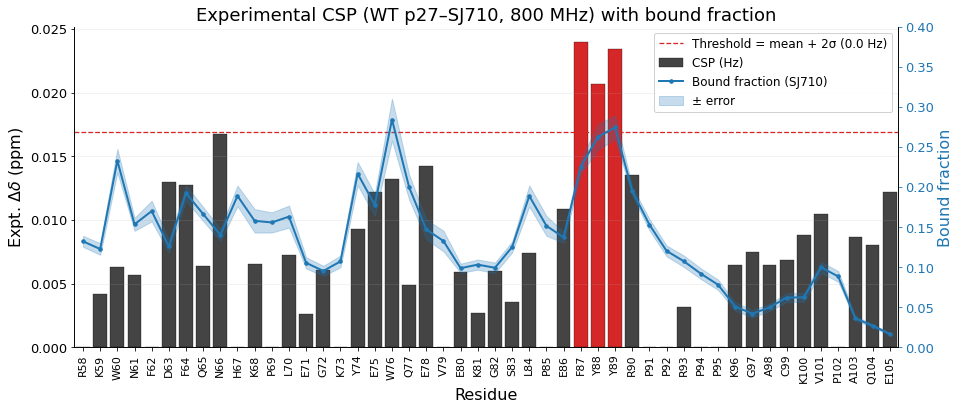

Saved plot -> csp_with_boundfrac_SJ710.png / .pdf


(<Figure size 967.68x417.6 with 2 Axes>,
 <AxesSubplot:title={'center':'Experimental CSP (WT p27–SJ710, 800 MHz) with bound fraction'}, xlabel='Residue', ylabel='Expt. $\\Delta \\delta$ (ppm)'>,
 <AxesSubplot:ylabel='Bound fraction'>)

In [18]:
"""
Experimental CSP (WT p27 + SJ710, 800 MHz) overlaid with a pre-computed
per-residue bound fraction.

Excel layout is the same as the WT_SJ403 file (two sheets with per-nucleus
CSPs in Hz, titration series `CSP[10]..CSP[3000]`, summary column at the
end). The only twist is sheet-name casing: this workbook uses `1H-CSP (Hz)`
(uppercase H) while the SJ403 one used `1h-CSP (Hz)` (lowercase). We find
sheets case-insensitively so the same loader handles both.

Inputs expected in memory:
    - `bf_sj7` : numpy array, shape (N, 3), columns = [resSeq, bf, error].
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------
EXCEL_PATH            = "WT_SJ710_800MHz.xlsx"
SPEC_MHZ_1H           = 800.0
GAMMA_N_OVER_GAMMA_H  = 0.10136767
SPEC_MHZ_15N          = SPEC_MHZ_1H * GAMMA_N_OVER_GAMMA_H
ALPHA_N               = 0.20

RES_MIN, RES_MAX         = 58, 105
THR_RES_MIN, THR_RES_MAX = 22, 105


# -----------------------------------------------------------------------------
# 1. Load and combine CSPs  — case-insensitive sheet lookup
# -----------------------------------------------------------------------------
def _find_sheet(xl, *needles):
    """Return the sheet whose name contains all substrings (case-insensitive)."""
    for s in xl.sheet_names:
        low = s.lower()
        if all(n.lower() in low for n in needles):
            return s
    raise KeyError(f"No sheet matching {needles} in {xl.sheet_names}")


def load_combined_csp(excel_path=EXCEL_PATH):
    xl = pd.ExcelFile(excel_path, engine="openpyxl")
    h_sheet = _find_sheet(xl, "1h",  "csp")
    n_sheet = _find_sheet(xl, "15n", "csp")
    h = pd.read_excel(xl, sheet_name=h_sheet)
    n = pd.read_excel(xl, sheet_name=n_sheet)

    # Per-nucleus summary column is the last one ('1H-CSP (Hz)' / '15N-CSP (Hz)')
    h_col = h.columns[-1]
    n_col = n.columns[-1]

    # Drop non-numeric residue rows (sidechain peaks, blank separators)
    h = h[pd.to_numeric(h["residue #"], errors="coerce").notna()].copy()
    n = n[pd.to_numeric(n["residue #"], errors="coerce").notna()].copy()
    h["residue #"] = h["residue #"].astype(int)
    n["residue #"] = n["residue #"].astype(int)

    merged = (
        h[["residue #", "Residue", h_col]]
        .merge(n[["residue #", n_col]], on="residue #", how="outer")
        .sort_values("residue #")
        .reset_index(drop=True)
    )

    dH_ppm = merged[h_col] / SPEC_MHZ_1H
    dN_ppm = merged[n_col] / SPEC_MHZ_15N
    csp_ppm = np.sqrt(dH_ppm.fillna(0) ** 2 + (ALPHA_N * dN_ppm.fillna(0)) ** 2)
    both_nan = merged[h_col].isna() & merged[n_col].isna()
    csp_ppm[both_nan] = np.nan
    csp_hz = csp_ppm * SPEC_MHZ_1H

    out = pd.DataFrame({
        "resSeq":  merged["residue #"].astype(int),
        "Residue": merged["Residue"],
        "dH_ppm":  dH_ppm,
        "dN_ppm":  dN_ppm,
        "CSP_ppm": csp_ppm,
        "CSP_Hz":  csp_hz,
    })
    out = (out.sort_values(["resSeq", "CSP_Hz"], na_position="last")
              .drop_duplicates("resSeq", keep="first")
              .reset_index(drop=True))
    return out


csp_df = load_combined_csp()

# -----------------------------------------------------------------------------
# 2. Threshold = mean + 2*std over residues 22-105 (Hz scale)
# -----------------------------------------------------------------------------
csp_thr_pool = csp_df.loc[
    (csp_df["resSeq"] >= THR_RES_MIN) & (csp_df["resSeq"] <= THR_RES_MAX),
    "CSP_ppm",
].dropna()
csp_mean = csp_thr_pool.mean()
csp_std  = csp_thr_pool.std(ddof=1)
csp_threshold = csp_mean + 2 * csp_std
print(f"SJ710 CSP statistics over residues {THR_RES_MIN}-{THR_RES_MAX} "
      f"(n={len(csp_thr_pool)}):")
print(f"  mean = {csp_mean:.2f} Hz,  std = {csp_std:.2f} Hz")
print(f"  threshold (mean + 2*std) = {csp_threshold:.2f} Hz")


# -----------------------------------------------------------------------------
# 3. Wrap the pre-computed bound-fraction array (bf_sj7) -> DataFrame
# -----------------------------------------------------------------------------
def bf_array_to_df(bf_arr):
    """Convert an (N, 3) array [resSeq, bound_frac, error] -> DataFrame."""
    bf_arr = np.asarray(bf_arr)
    if bf_arr.ndim != 2 or bf_arr.shape[1] < 3:
        raise ValueError(f"Expected (N, 3) array, got shape {bf_arr.shape}")
    df = pd.DataFrame({
        "resSeq":     bf_arr[:, 0].astype(int),
        "bound_frac": bf_arr[:, 1].astype(float),
        "sem":        bf_arr[:, 2].astype(float),
    })
    return df.drop_duplicates("resSeq").reset_index(drop=True)


bf_df = bf_array_to_df(bf_sj7)

# -----------------------------------------------------------------------------
# 4. Align both to residues 58-105
# -----------------------------------------------------------------------------
res_range = np.arange(RES_MIN, RES_MAX + 1)
csp_lookup = csp_df.drop_duplicates("resSeq").set_index("resSeq")
bf_lookup  = bf_df .drop_duplicates("resSeq").set_index("resSeq")

csp_p = csp_lookup.reindex(res_range).reset_index().rename(columns={"index": "resSeq"})
bf_p  = bf_lookup .reindex(res_range).reset_index().rename(columns={"index": "resSeq"})

assert len(csp_p) == len(bf_p) == len(res_range), \
    f"length mismatch: csp={len(csp_p)}, bf={len(bf_p)}, expected={len(res_range)}"

csp_p.merge(bf_p, on="resSeq", how="outer").to_csv(
    "csp_and_boundfrac_SJ710_58-105.csv", index=False)
print("Saved table -> csp_and_boundfrac_SJ710_58-105.csv")


# -----------------------------------------------------------------------------
# 5. Plot
# -----------------------------------------------------------------------------
_THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "HID": "H", "HIE": "H", "HIP": "H", "HSD": "H", "HSE": "H", "HSP": "H",
}


def _tick_labels(csp_p):
    labels = []
    for _, row in csp_p.iterrows():
        res_num = int(row["resSeq"])
        name = row.get("Residue")
        if isinstance(name, str) and name.strip():
            name = name.strip()
            if name[0].isalpha() and name[1:].lstrip("-").isdigit():
                labels.append(name)
                continue
            three = name[:3].upper()
            if three in _THREE_TO_ONE:
                labels.append(f"{_THREE_TO_ONE[three]}{res_num}")
                continue
        labels.append(f".{res_num}")
    return labels


def plot_csp_with_boundfrac(
    csp_p, bf_p, csp_threshold,
    *,
    title_fs=18,
    axis_label_fs=16,
    xtick_fs=11,
    ytick_fs=13,
    legend_fs=12,
    figsize=None,
    dpi=200,
    out_prefix="csp_with_boundfrac_SJ710",
    csp_color="#444444",
    csp_above_color="#d62728",
    bf_color="#1f77b4",
    threshold_color="#d62728",
    title="Experimental CSP (WT p27\u2013SJ710, 800 MHz) with bound fraction",
    bf_legend="Bound fraction (SJ710)",
    err_legend="\u00b1 error",
    legend_loc="upper right",
    legend_bbox=None,
    xtick_step=1,
    show=True,
):
    res = csp_p["resSeq"].values
    csp = csp_p["CSP_ppm"].values
    bf  = bf_p["bound_frac"].values
    err = bf_p["sem"].values
    labels = _tick_labels(csp_p)

    n = len(res)
    if figsize is None:
        figsize = (max(10, n * 0.28), 5.8)

    fig, ax = plt.subplots(figsize=figsize)

    bar_colors = [
        csp_above_color if (np.isfinite(c) and c >= csp_threshold) else csp_color
        for c in csp
    ]
    bar_heights = np.where(np.isnan(csp), 0.0, csp)
    ax.bar(res, bar_heights, color=bar_colors,
           edgecolor="black", linewidth=0.3, label="CSP (Hz)")

    ax.axhline(csp_threshold, color=threshold_color, linestyle="--",
               linewidth=1.3,
               label=f"Threshold = mean + 2\u03c3 ({csp_threshold:.1f} Hz)")
    
    # ax.axhline(10, color=threshold_color, linestyle="--",
    #            linewidth=1.3,
    #            label=f"Threshold = mean + 2\u03c3 ({csp_threshold:.1f} Hz)")

    ax.set_xlabel("Residue", fontsize=axis_label_fs)
    ax.set_ylabel('Expt. $\Delta \delta$ (ppm)', fontsize=axis_label_fs)
    ax.set_title(title, fontsize=title_fs)
    ax.tick_params(axis="y", labelsize=ytick_fs)
    ax.set_xlim(res.min() - 0.5, res.max() + 0.5)

    tick_idx = np.arange(0, n, xtick_step)
    ax.set_xticks(res[tick_idx])
    ax.set_xticklabels([labels[i] for i in tick_idx],
                       rotation=90, fontsize=xtick_fs)
    ax.spines["top"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)

    ax2 = ax.twinx()
    valid = np.isfinite(bf)
    ax2.plot(res[valid], bf[valid],
             color=bf_color, lw=2, marker="o", ms=3.5, label=bf_legend)
    ax2.fill_between(res[valid],
                     (bf - err)[valid],
                     (bf + err)[valid],
                     color=bf_color, alpha=0.25, label=err_legend)
    ax2.set_ylabel("Bound fraction", fontsize=axis_label_fs, color=bf_color)
    ax2.tick_params(axis="y", labelsize=ytick_fs, colors=bf_color)
    ax2.set_ylim(0, 0.4)
    ax2.spines["top"].set_visible(False)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg_kwargs = dict(fontsize=legend_fs, frameon=True, framealpha=0.9)
    if legend_bbox is not None:
        leg_kwargs.update(dict(loc=legend_loc, bbox_to_anchor=legend_bbox,
                               borderaxespad=0.))
    else:
        leg_kwargs["loc"] = legend_loc
    ax2.legend(lines1 + lines2, labels1 + labels2, **leg_kwargs)

    fig.tight_layout()
    fig.savefig(f"{out_prefix}.png", dpi=dpi)
    fig.savefig(f"{out_prefix}.pdf")
    if show:
        plt.show()
    print(f"Saved plot -> {out_prefix}.png / .pdf")
    return fig, ax, ax2


plot_csp_with_boundfrac(csp_p, bf_p, csp_threshold)

SJ749 CSP statistics over residues 22-121 (n=74):
  mean = 15.72 Hz,  std = 13.18 Hz
  threshold (mean + 2*std) = 42.08 Hz
Saved table -> csp_and_boundfrac_SJ749_58-105.csv


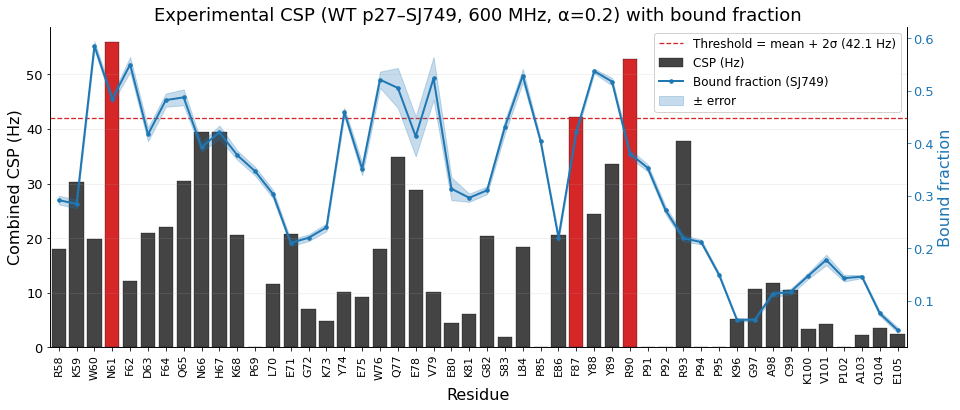

Saved plot -> csp_with_boundfrac_SJ749.png / .pdf


(<Figure size 967.68x417.6 with 2 Axes>,
 <AxesSubplot:title={'center':'Experimental CSP (WT p27–SJ749, 600 MHz, α=0.2) with bound fraction'}, xlabel='Residue', ylabel='Combined CSP (Hz)'>,
 <AxesSubplot:ylabel='Bound fraction'>)

In [13]:
"""
Experimental CSP (WT p27 + SJ749, 600 MHz) overlaid with a pre-computed
per-residue bound fraction.

This workbook has a different layout from SJ403/SJ710:
    - Sheet `CSP (ppm)` holds *already-combined* CSPs in ppm (Dd100, Dd200,
      Dd400, Dd800, Dd1200, Dd1600), but we don't know what alpha was used
      to combine them, so they're not suitable once the user requests a
      specific alpha.
    - Sheet `CS` is a wide "raw chemical shifts" sheet with two header rows.
      The only titration point with per-nucleus CSPs (in Hz) pre-computed is
      the 800 uM point: columns labeled `Dd800[1H]` and `Dd800[15N]`.

So the loader reads the `CS` sheet with header=None, locates those three
columns (`Residue`, `Dd800[1H]`, `Dd800[15N]`) by case-insensitive exact
match on their labels, filters to backbone residues (`^[A-Z]\\d+$`), then
combines with alpha = 0.2 at 600 MHz.

Inputs expected in memory:
    - `bf_sj9` : numpy array, shape (N, 3), [resSeq, bound_frac, error].
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------
EXCEL_PATH            = "WT_SJ9_600MHz.xlsx"
CS_SHEET              = "CS"                     # per-nucleus Hz only lives here
SPEC_MHZ_1H           = 600.0                    # <-- 600 MHz this time
GAMMA_N_OVER_GAMMA_H  = 0.10136767
SPEC_MHZ_15N          = SPEC_MHZ_1H * GAMMA_N_OVER_GAMMA_H
ALPHA_N               = 0.2                      # <-- user requested 0.2

RES_MIN, RES_MAX         = 58, 105
THR_RES_MIN, THR_RES_MAX = 22, 121

RESIDUE_REGEX = re.compile(r"^([A-Z])(\d+)$")


# -----------------------------------------------------------------------------
# 1. Load per-nucleus Dd800 CSPs from the `CS` sheet
# -----------------------------------------------------------------------------
def _find_header_cells(raw, targets, max_rows=6):
    """Search the first `max_rows` rows for exact text matches (case-insensitive,
    whitespace-stripped). Returns dict target -> (row, col) or None."""
    out = {t: None for t in targets}
    for r in range(min(max_rows, len(raw))):
        for c in range(raw.shape[1]):
            v = str(raw.iat[r, c]).strip().lower().replace(" ", "")
            for t in targets:
                if v == t and out[t] is None:
                    out[t] = (r, c)
    return out


def load_combined_csp_sj749(excel_path=EXCEL_PATH, sheet=CS_SHEET):
    raw = pd.read_excel(excel_path, sheet_name=sheet,
                        engine="openpyxl", header=None)

    targets = ["residue", "dd800[1h]", "dd800[15n]"]
    locs = _find_header_cells(raw, targets)
    missing = [t for t, v in locs.items() if v is None]
    if missing:
        raise KeyError(
            f"Could not find {missing} in the '{sheet}' sheet of {excel_path}.\n"
            f"First 3 rows of the sheet for debugging:\n{raw.head(3).to_string()}"
        )

    res_col = locs["residue"][1]
    h_col   = locs["dd800[1h]"][1]
    n_col   = locs["dd800[15n]"][1]
    hdr_row = max(v[0] for v in locs.values())

    data = raw.iloc[hdr_row + 1:].reset_index(drop=True)
    res   = data.iloc[:, res_col].astype(str).str.strip()
    dH_hz = pd.to_numeric(data.iloc[:, h_col], errors="coerce")
    dN_hz = pd.to_numeric(data.iloc[:, n_col], errors="coerce")

    # Keep only rows whose Residue label looks like 'E22' / 'W76' — this drops
    # blank rows, sidechain peaks ('s-Q40-NH1'), and any trailing junk.
    mask = res.str.match(RESIDUE_REGEX.pattern)
    res   = res  [mask].reset_index(drop=True)
    dH_hz = dH_hz[mask].reset_index(drop=True)
    dN_hz = dN_hz[mask].reset_index(drop=True)

    resSeq = res.str.extract(RESIDUE_REGEX.pattern)[1].astype(int)

    # Hz -> ppm, then Williamson combination with alpha = 0.2
    dH_ppm = dH_hz / SPEC_MHZ_1H
    dN_ppm = dN_hz / SPEC_MHZ_15N
    csp_ppm = np.sqrt(dH_ppm.fillna(0) ** 2 + (ALPHA_N * dN_ppm.fillna(0)) ** 2)
    both_nan = dH_ppm.isna() & dN_ppm.isna()
    csp_ppm[both_nan] = np.nan
    csp_hz = csp_ppm * SPEC_MHZ_1H

    out = pd.DataFrame({
        "resSeq":  resSeq.values,
        "Residue": res.values,
        "dH_ppm":  dH_ppm.values,
        "dN_ppm":  dN_ppm.values,
        "CSP_ppm": csp_ppm.values,
        "CSP_Hz":  csp_hz.values,
    })
    out = (out.sort_values(["resSeq", "CSP_Hz"], na_position="last")
              .drop_duplicates("resSeq", keep="first")
              .reset_index(drop=True))
    return out


csp_df = load_combined_csp_sj749()

# -----------------------------------------------------------------------------
# 2. Threshold = mean + 2*std over residues 22-105 (Hz scale)
# -----------------------------------------------------------------------------
csp_thr_pool = csp_df.loc[
    (csp_df["resSeq"] >= THR_RES_MIN) & (csp_df["resSeq"] <= THR_RES_MAX),
    "CSP_Hz",
].dropna()
csp_mean = csp_thr_pool.mean()
csp_std  = csp_thr_pool.std(ddof=1)
csp_threshold = csp_mean + 2 * csp_std
print(f"SJ749 CSP statistics over residues {THR_RES_MIN}-{THR_RES_MAX} "
      f"(n={len(csp_thr_pool)}):")
print(f"  mean = {csp_mean:.2f} Hz,  std = {csp_std:.2f} Hz")
print(f"  threshold (mean + 2*std) = {csp_threshold:.2f} Hz")


# -----------------------------------------------------------------------------
# 3. Wrap bf_sj9 -> DataFrame
# -----------------------------------------------------------------------------
def bf_array_to_df(bf_arr):
    bf_arr = np.asarray(bf_arr)
    if bf_arr.ndim != 2 or bf_arr.shape[1] < 3:
        raise ValueError(f"Expected (N, 3) array, got shape {bf_arr.shape}")
    return pd.DataFrame({
        "resSeq":     bf_arr[:, 0].astype(int),
        "bound_frac": bf_arr[:, 1].astype(float),
        "sem":        bf_arr[:, 2].astype(float),
    }).drop_duplicates("resSeq").reset_index(drop=True)


bf_df = bf_array_to_df(bf_sj9)

# -----------------------------------------------------------------------------
# 4. Align to 58-105
# -----------------------------------------------------------------------------
res_range = np.arange(RES_MIN, RES_MAX + 1)
csp_lookup = csp_df.drop_duplicates("resSeq").set_index("resSeq")
bf_lookup  = bf_df .drop_duplicates("resSeq").set_index("resSeq")
csp_p = csp_lookup.reindex(res_range).reset_index().rename(columns={"index": "resSeq"})
bf_p  = bf_lookup .reindex(res_range).reset_index().rename(columns={"index": "resSeq"})
assert len(csp_p) == len(bf_p) == len(res_range), \
    f"length mismatch: csp={len(csp_p)}, bf={len(bf_p)}, expected={len(res_range)}"

csp_p.merge(bf_p, on="resSeq", how="outer").to_csv(
    "csp_and_boundfrac_SJ749_58-105.csv", index=False)
print("Saved table -> csp_and_boundfrac_SJ749_58-105.csv")


# -----------------------------------------------------------------------------
# 5. Plot
# -----------------------------------------------------------------------------
_THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "HID": "H", "HIE": "H", "HIP": "H", "HSD": "H", "HSE": "H", "HSP": "H",
}


def _tick_labels(csp_p):
    labels = []
    for _, row in csp_p.iterrows():
        res_num = int(row["resSeq"])
        name = row.get("Residue")
        if isinstance(name, str) and name.strip():
            name = name.strip()
            if name[0].isalpha() and name[1:].lstrip("-").isdigit():
                labels.append(name)
                continue
            three = name[:3].upper()
            if three in _THREE_TO_ONE:
                labels.append(f"{_THREE_TO_ONE[three]}{res_num}")
                continue
        labels.append(f".{res_num}")
    return labels


def plot_csp_with_boundfrac(
    csp_p, bf_p, csp_threshold,
    *,
    title_fs=18,
    axis_label_fs=16,
    xtick_fs=11,
    ytick_fs=13,
    legend_fs=12,
    figsize=None,
    dpi=200,
    out_prefix="csp_with_boundfrac_SJ749",
    csp_color="#444444",
    csp_above_color="#d62728",
    bf_color="#1f77b4",
    threshold_color="#d62728",
    title="Experimental CSP (WT p27\u2013SJ749, 600 MHz, \u03b1=0.2) with bound fraction",
    bf_legend="Bound fraction (SJ749)",
    err_legend="\u00b1 error",
    legend_loc="upper right",
    legend_bbox=None,
    xtick_step=1,
    show=True,
):
    res = csp_p["resSeq"].values
    csp = csp_p["CSP_Hz"].values
    bf  = bf_p["bound_frac"].values
    err = bf_p["sem"].values
    labels = _tick_labels(csp_p)

    n = len(res)
    if figsize is None:
        figsize = (max(10, n * 0.28), 5.8)

    fig, ax = plt.subplots(figsize=figsize)

    bar_colors = [
        csp_above_color if (np.isfinite(c) and c >= csp_threshold) else csp_color
        for c in csp
    ]
    bar_heights = np.where(np.isnan(csp), 0.0, csp)
    ax.bar(res, bar_heights, color=bar_colors,
           edgecolor="black", linewidth=0.3, label="CSP (Hz)")

    ax.axhline(csp_threshold, color=threshold_color, linestyle="--",
               linewidth=1.3,
               label=f"Threshold = mean + 2\u03c3 ({csp_threshold:.1f} Hz)")

    ax.set_xlabel("Residue", fontsize=axis_label_fs)
    ax.set_ylabel("Combined CSP (Hz)", fontsize=axis_label_fs)
    ax.set_title(title, fontsize=title_fs)
    ax.tick_params(axis="y", labelsize=ytick_fs)
    ax.set_xlim(res.min() - 0.5, res.max() + 0.5)

    tick_idx = np.arange(0, n, xtick_step)
    ax.set_xticks(res[tick_idx])
    ax.set_xticklabels([labels[i] for i in tick_idx],
                       rotation=90, fontsize=xtick_fs)
    ax.spines["top"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)

    ax2 = ax.twinx()
    valid = np.isfinite(bf)
    ax2.plot(res[valid], bf[valid],
             color=bf_color, lw=2, marker="o", ms=3.5, label=bf_legend)
    ax2.fill_between(res[valid],
                     (bf - err)[valid],
                     (bf + err)[valid],
                     color=bf_color, alpha=0.25, label=err_legend)
    ax2.set_ylabel("Bound fraction", fontsize=axis_label_fs, color=bf_color)
    ax2.tick_params(axis="y", labelsize=ytick_fs, colors=bf_color)
    # ax2.set_ylim(0, 0.6)
    ax2.spines["top"].set_visible(False)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg_kwargs = dict(fontsize=legend_fs, frameon=True, framealpha=0.9)
    if legend_bbox is not None:
        leg_kwargs.update(dict(loc=legend_loc, bbox_to_anchor=legend_bbox,
                               borderaxespad=0.))
    else:
        leg_kwargs["loc"] = legend_loc
    ax2.legend(lines1 + lines2, labels1 + labels2, **leg_kwargs)

    fig.tight_layout()
    fig.savefig(f"{out_prefix}.png", dpi=dpi)
    fig.savefig(f"{out_prefix}.pdf")
    if show:
        plt.show()
    print(f"Saved plot -> {out_prefix}.png / .pdf")
    return fig, ax, ax2


plot_csp_with_boundfrac(csp_p, bf_p, csp_threshold)

SJ749 CSP statistics over residues 22-121 (n=74):
  mean = 0.0262 ppm,  std = 0.0220 ppm
  threshold (mean + 2*std) = 0.0701 ppm
Saved table -> csp_and_boundfrac_SJ749_58-105.csv


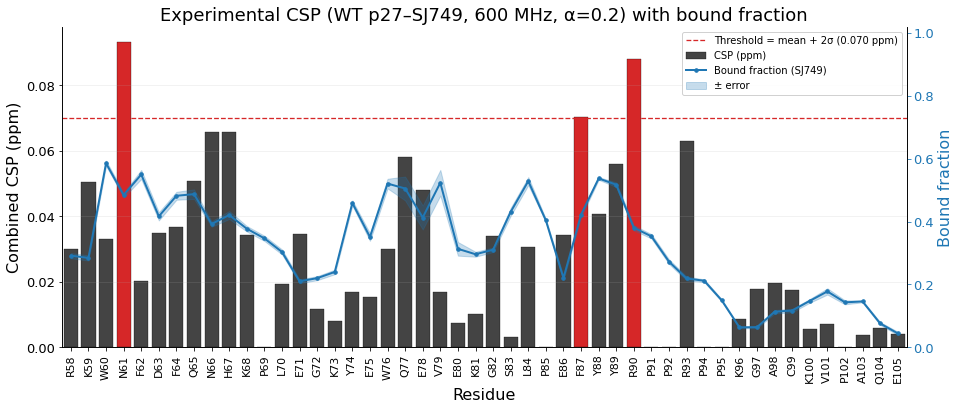

Saved plot -> csp_with_boundfrac_SJ749.png / .pdf


(<Figure size 967.68x417.6 with 2 Axes>,
 <AxesSubplot:title={'center':'Experimental CSP (WT p27–SJ749, 600 MHz, α=0.2) with bound fraction'}, xlabel='Residue', ylabel='Combined CSP (ppm)'>,
 <AxesSubplot:ylabel='Bound fraction'>)

In [14]:
"""
Experimental CSP (WT p27 + SJ749, 600 MHz) overlaid with a pre-computed
per-residue bound fraction.

This workbook has a different layout from SJ403/SJ710:
    - Sheet `CSP (ppm)` holds *already-combined* CSPs in ppm (Dd100, Dd200,
      Dd400, Dd800, Dd1200, Dd1600), but we don't know what alpha was used
      to combine them, so they're not suitable once the user requests a
      specific alpha.
    - Sheet `CS` is a wide "raw chemical shifts" sheet with two header rows.
      The only titration point with per-nucleus CSPs (in Hz) pre-computed is
      the 800 uM point: columns labeled `Dd800[1H]` and `Dd800[15N]`.

So the loader reads the `CS` sheet with header=None, locates those three
columns (`Residue`, `Dd800[1H]`, `Dd800[15N]`) by case-insensitive exact
match on their labels, filters to backbone residues (`^[A-Z]\\d+$`), then
combines with alpha = 0.2 at 600 MHz.

Inputs expected in memory:
    - `bf_sj9` : numpy array, shape (N, 3), [resSeq, bound_frac, error].
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------
EXCEL_PATH            = "WT_SJ9_600MHz.xlsx"
CS_SHEET              = "CS"                     # per-nucleus Hz only lives here
SPEC_MHZ_1H           = 600.0                    # <-- 600 MHz this time
GAMMA_N_OVER_GAMMA_H  = 0.10136767
SPEC_MHZ_15N          = SPEC_MHZ_1H * GAMMA_N_OVER_GAMMA_H
ALPHA_N               = 0.2                      # <-- user requested 0.2

# Plot range
RES_MIN, RES_MAX         = 58, 105

# Residue range used to compute the CSP threshold statistics
# (NB: the SJ749 workbook has backbone residues E22-S121, so if the paper
# used the full assigned range the threshold would come from 22-121, not
# 22-105 like the other ligands. Change these two lines if needed.)
THR_RES_MIN, THR_RES_MAX = 22, 121

RESIDUE_REGEX = re.compile(r"^([A-Z])(\d+)$")


# -----------------------------------------------------------------------------
# 1. Load per-nucleus Dd800 CSPs from the `CS` sheet
# -----------------------------------------------------------------------------
def _find_header_cells(raw, targets, max_rows=6):
    """Search the first `max_rows` rows for exact text matches (case-insensitive,
    whitespace-stripped). Returns dict target -> (row, col) or None."""
    out = {t: None for t in targets}
    for r in range(min(max_rows, len(raw))):
        for c in range(raw.shape[1]):
            v = str(raw.iat[r, c]).strip().lower().replace(" ", "")
            for t in targets:
                if v == t and out[t] is None:
                    out[t] = (r, c)
    return out


def load_combined_csp_sj749(excel_path=EXCEL_PATH, sheet=CS_SHEET):
    raw = pd.read_excel(excel_path, sheet_name=sheet,
                        engine="openpyxl", header=None)

    targets = ["residue", "dd800[1h]", "dd800[15n]"]
    locs = _find_header_cells(raw, targets)
    missing = [t for t, v in locs.items() if v is None]
    if missing:
        raise KeyError(
            f"Could not find {missing} in the '{sheet}' sheet of {excel_path}.\n"
            f"First 3 rows of the sheet for debugging:\n{raw.head(3).to_string()}"
        )

    res_col = locs["residue"][1]
    h_col   = locs["dd800[1h]"][1]
    n_col   = locs["dd800[15n]"][1]
    hdr_row = max(v[0] for v in locs.values())

    data = raw.iloc[hdr_row + 1:].reset_index(drop=True)
    res   = data.iloc[:, res_col].astype(str).str.strip()
    dH_hz = pd.to_numeric(data.iloc[:, h_col], errors="coerce")
    dN_hz = pd.to_numeric(data.iloc[:, n_col], errors="coerce")

    # Keep only rows whose Residue label looks like 'E22' / 'W76' — this drops
    # blank rows, sidechain peaks ('s-Q40-NH1'), and any trailing junk.
    mask = res.str.match(RESIDUE_REGEX.pattern)
    res   = res  [mask].reset_index(drop=True)
    dH_hz = dH_hz[mask].reset_index(drop=True)
    dN_hz = dN_hz[mask].reset_index(drop=True)

    resSeq = res.str.extract(RESIDUE_REGEX.pattern)[1].astype(int)

    # Hz -> ppm, then Williamson combination with alpha = 0.2
    dH_ppm = dH_hz / SPEC_MHZ_1H
    dN_ppm = dN_hz / SPEC_MHZ_15N
    csp_ppm = np.sqrt(dH_ppm.fillna(0) ** 2 + (ALPHA_N * dN_ppm.fillna(0)) ** 2)
    both_nan = dH_ppm.isna() & dN_ppm.isna()
    csp_ppm[both_nan] = np.nan
    csp_hz = csp_ppm * SPEC_MHZ_1H

    out = pd.DataFrame({
        "resSeq":  resSeq.values,
        "Residue": res.values,
        "dH_ppm":  dH_ppm.values,
        "dN_ppm":  dN_ppm.values,
        "CSP_ppm": csp_ppm.values,
        "CSP_Hz":  csp_hz.values,
    })
    out = (out.sort_values(["resSeq", "CSP_Hz"], na_position="last")
              .drop_duplicates("resSeq", keep="first")
              .reset_index(drop=True))
    return out


csp_df = load_combined_csp_sj749()

# -----------------------------------------------------------------------------
# 2. Threshold = mean + 2*std on the ppm scale, over residues
#    [THR_RES_MIN .. THR_RES_MAX].
# -----------------------------------------------------------------------------
csp_thr_pool = csp_df.loc[
    (csp_df["resSeq"] >= THR_RES_MIN) & (csp_df["resSeq"] <= THR_RES_MAX),
    "CSP_ppm",
].dropna()
csp_mean = csp_thr_pool.mean()
csp_std  = csp_thr_pool.std(ddof=1)
csp_threshold = csp_mean + 2 * csp_std
print(f"SJ749 CSP statistics over residues {THR_RES_MIN}-{THR_RES_MAX} "
      f"(n={len(csp_thr_pool)}):")
print(f"  mean = {csp_mean:.4f} ppm,  std = {csp_std:.4f} ppm")
print(f"  threshold (mean + 2*std) = {csp_threshold:.4f} ppm")


# -----------------------------------------------------------------------------
# 3. Wrap bf_sj9 -> DataFrame
# -----------------------------------------------------------------------------
def bf_array_to_df(bf_arr):
    bf_arr = np.asarray(bf_arr)
    if bf_arr.ndim != 2 or bf_arr.shape[1] < 3:
        raise ValueError(f"Expected (N, 3) array, got shape {bf_arr.shape}")
    return pd.DataFrame({
        "resSeq":     bf_arr[:, 0].astype(int),
        "bound_frac": bf_arr[:, 1].astype(float),
        "sem":        bf_arr[:, 2].astype(float),
    }).drop_duplicates("resSeq").reset_index(drop=True)


bf_df = bf_array_to_df(bf_sj9)

# -----------------------------------------------------------------------------
# 4. Align to 58-105
# -----------------------------------------------------------------------------
res_range = np.arange(RES_MIN, RES_MAX + 1)
csp_lookup = csp_df.drop_duplicates("resSeq").set_index("resSeq")
bf_lookup  = bf_df .drop_duplicates("resSeq").set_index("resSeq")
csp_p = csp_lookup.reindex(res_range).reset_index().rename(columns={"index": "resSeq"})
bf_p  = bf_lookup .reindex(res_range).reset_index().rename(columns={"index": "resSeq"})
assert len(csp_p) == len(bf_p) == len(res_range), \
    f"length mismatch: csp={len(csp_p)}, bf={len(bf_p)}, expected={len(res_range)}"

csp_p.merge(bf_p, on="resSeq", how="outer").to_csv(
    "csp_and_boundfrac_SJ749_58-105.csv", index=False)
print("Saved table -> csp_and_boundfrac_SJ749_58-105.csv")


# -----------------------------------------------------------------------------
# 5. Plot
# -----------------------------------------------------------------------------
_THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "HID": "H", "HIE": "H", "HIP": "H", "HSD": "H", "HSE": "H", "HSP": "H",
}


def _tick_labels(csp_p):
    labels = []
    for _, row in csp_p.iterrows():
        res_num = int(row["resSeq"])
        name = row.get("Residue")
        if isinstance(name, str) and name.strip():
            name = name.strip()
            if name[0].isalpha() and name[1:].lstrip("-").isdigit():
                labels.append(name)
                continue
            three = name[:3].upper()
            if three in _THREE_TO_ONE:
                labels.append(f"{_THREE_TO_ONE[three]}{res_num}")
                continue
        labels.append(f".{res_num}")
    return labels


def plot_csp_with_boundfrac(
    csp_p, bf_p, csp_threshold,
    *,
    title_fs=18,
    axis_label_fs=16,
    xtick_fs=11,
    ytick_fs=13,
    legend_fs=12,
    figsize=None,
    dpi=200,
    out_prefix="csp_with_boundfrac_SJ749",
    csp_color="#444444",
    csp_above_color="#d62728",
    bf_color="#1f77b4",
    threshold_color="#d62728",
    title="Experimental CSP (WT p27\u2013SJ749, 600 MHz, \u03b1=0.2) with bound fraction",
    csp_fmt="{:.3f} ppm",          # how the threshold value is rendered in legend
    bf_legend="Bound fraction (SJ749)",
    err_legend="\u00b1 error",
    legend_loc="upper right",
    legend_bbox=None,
    xtick_step=1,
    show=True,
):
    res = csp_p["resSeq"].values
    csp = csp_p["CSP_ppm"].values
    bf  = bf_p["bound_frac"].values
    err = bf_p["sem"].values
    labels = _tick_labels(csp_p)

    n = len(res)
    if figsize is None:
        figsize = (max(10, n * 0.28), 5.8)

    fig, ax = plt.subplots(figsize=figsize)

    bar_colors = [
        csp_above_color if (np.isfinite(c) and c >= csp_threshold) else csp_color
        for c in csp
    ]
    bar_heights = np.where(np.isnan(csp), 0.0, csp)
    ax.bar(res, bar_heights, color=bar_colors,
           edgecolor="black", linewidth=0.3, label="CSP (ppm)")

    ax.axhline(csp_threshold, color=threshold_color, linestyle="--",
               linewidth=1.3,
               label=f"Threshold = mean + 2\u03c3 ({csp_fmt.format(csp_threshold)})")
    
    # ax.axhline(0.05, color=threshold_color, linestyle="--",
    #         linewidth=1.3,
    #         label=f"Threshold = mean + 2\u03c3 ({csp_fmt.format(csp_threshold)})")

    ax.set_xlabel("Residue", fontsize=axis_label_fs)
    ax.set_ylabel("Combined CSP (ppm)", fontsize=axis_label_fs)
    ax.set_title(title, fontsize=title_fs)
    ax.tick_params(axis="y", labelsize=ytick_fs)
    ax.set_xlim(res.min() - 0.5, res.max() + 0.5)

    tick_idx = np.arange(0, n, xtick_step)
    ax.set_xticks(res[tick_idx])
    ax.set_xticklabels([labels[i] for i in tick_idx],
                       rotation=90, fontsize=xtick_fs)
    ax.spines["top"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)

    ax2 = ax.twinx()
    valid = np.isfinite(bf)
    ax2.plot(res[valid], bf[valid],
             color=bf_color, lw=2, marker="o", ms=3.5, label=bf_legend)
    ax2.fill_between(res[valid],
                     (bf - err)[valid],
                     (bf + err)[valid],
                     color=bf_color, alpha=0.25, label=err_legend)
    ax2.set_ylabel("Bound fraction", fontsize=axis_label_fs, color=bf_color)
    ax2.tick_params(axis="y", labelsize=ytick_fs, colors=bf_color)
    ax2.set_ylim(0, 1.02)
    ax2.spines["top"].set_visible(False)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg_kwargs = dict(fontsize=10, frameon=True, framealpha=0.9)
    if legend_bbox is not None:
        leg_kwargs.update(dict(loc=legend_loc, bbox_to_anchor=legend_bbox,
                               borderaxespad=0.))
    else:
        leg_kwargs["loc"] = legend_loc
    ax2.legend(lines1 + lines2, labels1 + labels2, **leg_kwargs)

    fig.tight_layout()
    fig.savefig(f"{out_prefix}.png", dpi=dpi)
    fig.savefig(f"{out_prefix}.pdf")
    if show:
        plt.show()
    print(f"Saved plot -> {out_prefix}.png / .pdf")
    return fig, ax, ax2


plot_csp_with_boundfrac(csp_p, bf_p, csp_threshold)